In [53]:
!pip install pmdarima

In [55]:
import pandas as pd
import numpy as np
# Needed to run the logistic regression
import statsmodels.formula.api as smf

# Confusion Matrix
from sklearn.metrics import confusion_matrix

#Testing and Traing Model
from sklearn.model_selection import train_test_split

# Scaling the data
from sklearn.preprocessing import StandardScaler

# Logistic Regression
from sklearn.linear_model import LogisticRegression

# For plotting/checking assumptions
import seaborn as sns



In [79]:
df= pd.read_csv("PD.csv")
df.head()

,trans_date,member_id,supplier_id,total
0,31/01/2023,200001,100020,15252.00
1,28/02/2023,200001,100020,3844.44
2,31/03/2023,200001,100020,8648.57
3,30/04/2023,200001,100020,18210.52
4,31/05/2023,200001,100020,19070.63


In [80]:
df.drop(['member_id', 'supplier_id'], axis=1, inplace=True)

In [81]:
df.head()

,trans_date,total
0,31/01/2023,15252.00
1,28/02/2023,3844.44
2,31/03/2023,8648.57
3,30/04/2023,18210.52
4,31/05/2023,19070.63


In [83]:
df['trans_date'] = pd.to_datetime(df['trans_date'], dayfirst=True)

In [84]:
df.head()

,trans_date,total
0,2023-01-31,15252.00
1,2023-02-28,3844.44
2,2023-03-31,8648.57
3,2023-04-30,18210.52
4,2023-05-31,19070.63


In [85]:
df = df.set_index('trans_date', drop=True)

In [86]:
df.head()

,total
trans_date,
2023-01-31,15252.00
2023-02-28,3844.44
2023-03-31,8648.57
2023-04-30,18210.52
2023-05-31,19070.63


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 32 entries, 2023-01-31 to 2025-08-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   total   32 non-null     float64
dtypes: float64(1)
memory usage: 512.0 bytes


<Axes: xlabel='trans_date'>

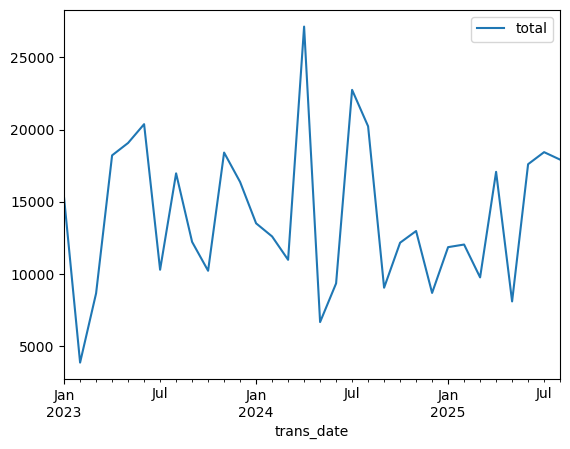

In [88]:
df.plot()

Test to see if data is stationary

In [89]:
from statsmodels.tsa.stattools import adfuller

In [90]:
test_result = adfuller(df['total'])

In [91]:
def adfuller_test(total):
    result = adfuller(total)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used', 'Critical Values:']
    for value,label in zip(result, labels):
        print(label + ' : ' + str(value) )

In [92]:
adfuller_test(df['total'])

ADF Test Statistic : -5.3101895476688625
p-value : 5.21571669830468e-06
#Lags Used : 1
Number of Observations Used : 30
Critical Values: : {'1%': -3.6699197407407405, '5%': -2.9640707407407407, '10%': -2.621171111111111}


Data is stationary as the p-value is below 0.05 and the Test Statistic is less than all Critical Values. Now use Autoarima to work out the idea auto and partial correction.

In [68]:
import pmdarima as pmd

In [93]:
from pmdarima import auto_arima

In [97]:
auto_model = auto_arima(
    df['total'],
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=0,               # already stationary
    seasonal=True,
    m=12,              # monthly data (12 periods per year)
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    D=0,
    trace=True,
    stepwise=True,
    information_criterion='aic'
)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=641.248, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=644.693, Time=0.04 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=644.291, Time=0.02 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=707.871, Time=0.01 sec
 ARIMA(0,0,0)(1,0,0)[12] intercept   : AIC=643.132, Time=0.01 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=642.110, Time=0.01 sec
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=644.107, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=643.094, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=643.400, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=645.252, Time=0.01 sec

Best model:  ARIMA(0,0,0)(0,0,0)[12] intercept
Total fit time: 0.161 seconds


In [112]:
train = df.loc[:'2025-04-30']
test  = df.loc['2025-05-01':]

In [145]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train['total'],
    order=(1,0,1),
    seasonal_order=(0,1,1,12)
)
result = model.fit()

pred = result.get_forecast(steps=len(test))
pred_mean = pred.predicted_mean
pred_ci = pred.conf_int()

c:\Users\AhmedLawal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
c:\Users\AhmedLawal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
c:\Users\AhmedLawal\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


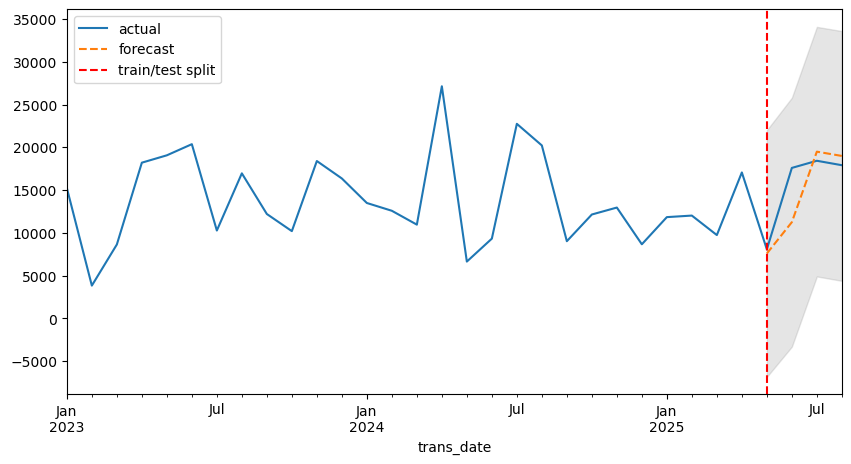

In [146]:
import matplotlib.pyplot as plt

ax = df['total'].plot(label='actual', figsize=(10,5))
pred_mean.plot(ax=ax, style='--', label='forecast')
ax.fill_between(pred_ci.index, pred_ci.iloc[:,0], pred_ci.iloc[:,1], color='gray', alpha=0.2)
ax.axvline(test.index[0], color='red', linestyle='--', label='train/test split')
ax.legend()
plt.show()

Calculate Forecast Accuracy:Typical guidance:

MAPE < 10 %: excellent

10–20 %: good

20–50 %: fair

50 %: poor fit

In [136]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test['total'], pred_mean)
rmse = np.sqrt(mean_squared_error(test['total'], pred_mean))
mape = np.mean(np.abs((test['total'] - pred_mean) / test['total'])) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 2244.76
RMSE: 3269.44
MAPE: 13.48%
